# 09 · Studi Kasus Nyata: KasPintar, Sistem Rekomendasi Pengisian Kas ATM

## Masalah
Bank mengisi ATM secara berkala lewat jasa pengangkutan uang (*cash-in-transit*), misalnya **setiap Senin**.
Jumlah yang diisi harus cukup sampai Senin berikutnya.

| Jika diisi… | Akibatnya |
|---|---|
| **terlalu sedikit** | ATM kosong → nasabah kecewa, kunjungan darurat mahal, reputasi turun (di Indonesia paling terasa menjelang **Lebaran**) |
| **terlalu banyak** | uang menganggur di mesin → biaya dana, asuransi, risiko keamanan |

Praktik umum: **"rata-rata 4 minggu terakhir × 1,2"**. Ini satu angka tanpa ukuran risiko.
Selain itu, data transaksi tiap bank **rahasia**, dan **ATM/bank baru** belum punya histori.

> **Pertanyaan bisnis:** berapa uang yang harus diisi ke tiap ATM minggu ini agar peluang kehabisan
> ≤ 5%, dengan uang menganggur seminimal mungkin?

Pertanyaan ini membutuhkan ketiga hal dalam pertanyaan riset: **akurat**, **jujur soal ketidakpastian**,
dan **belajar tanpa berbagi data**.

## Data riil: NN5
Penarikan tunai harian dari **111 ATM di Inggris** (18 Mar 1996 – 17 Mei 1998), dari kompetisi forecasting
NN5. Sumber: Zenodo (Monash Forecasting Archive), lisensi **CC BY 4.0**. Nilai sudah diskalakan oleh
penyelenggara, jadi di sini disebut "unit kas".

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
from fedprob.realdata.nn5 import load_nn5, holiday_effect, UK_HOLIDAYS
d = load_nn5()
df = d.to_frame()
print(f"{d.y.shape[1]} ATM x {d.y.shape[0]} hari: {d.dates[0].date()} s/d {d.dates[-1].date()}")
print(f"nilai hilang: {np.isnan(d.raw).mean():.1%}, nilai nol: {(d.raw == 0).mean():.1%} -> diimputasi (median hari sama 4 minggu terakhir)")
df.iloc[:5, :6]

111 ATM x 791 hari: 1996-03-18 s/d 1998-05-17
nilai hilang: 1.9%, nilai nol: 0.5% -> diimputasi (median hari sama 4 minggu terakhir)


,T1,T2,T3,T4,T5,T6
1996-03-18,13.407,11.550,5.641,13.180,9.779,9.240
1996-03-19,14.725,13.591,14.399,8.447,10.813,11.635
1996-03-20,20.564,15.037,24.419,19.515,21.613,12.103
1996-03-21,34.708,21.570,28.784,28.883,38.520,21.414
1996-03-22,26.630,19.444,20.621,19.473,24.745,24.674


## Pola: mingguan, hari libur, dan variasi antar ATM

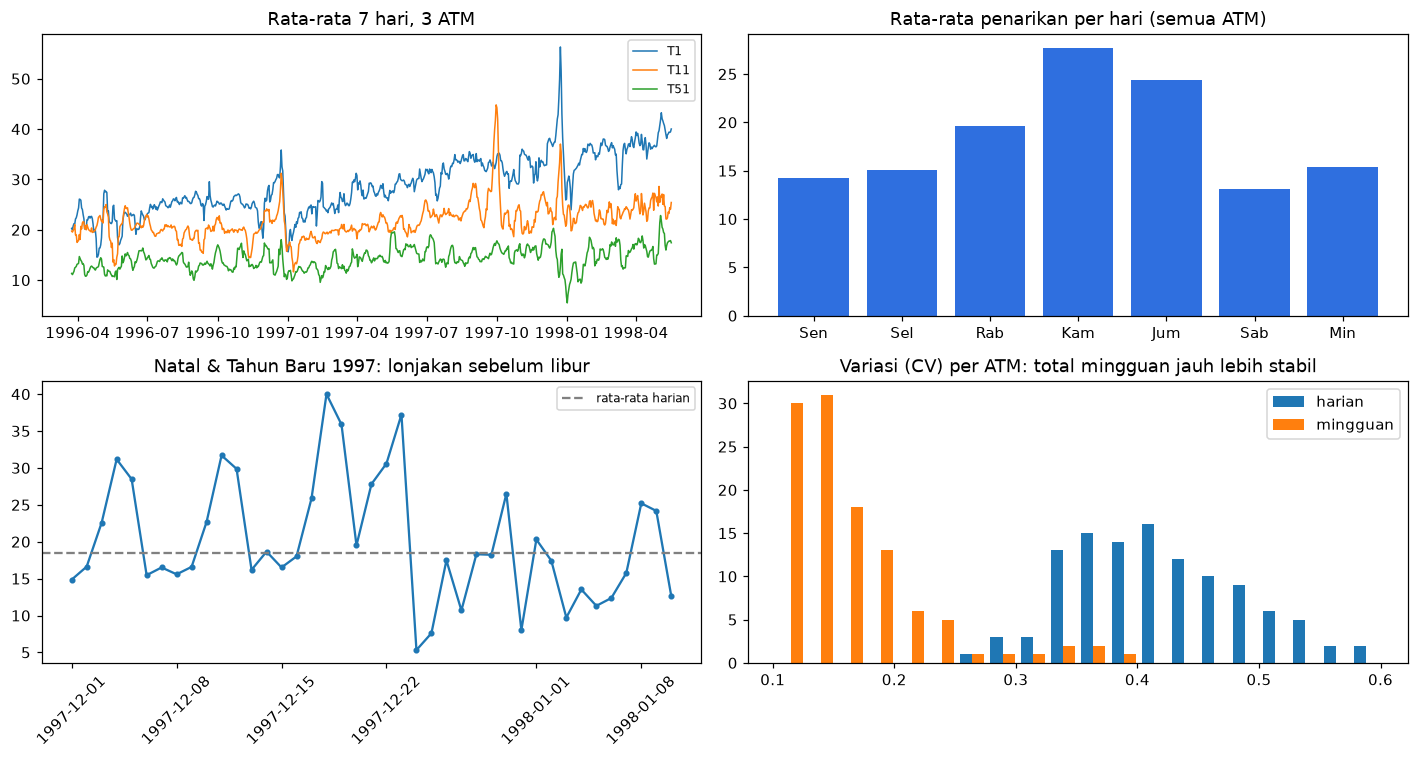

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for j in [0, 10, 50]:
    axes[0, 0].plot(df.index, df.iloc[:, j].rolling(7).mean(), lw=1, label=d.names[j])
axes[0, 0].set_title("Rata-rata 7 hari, 3 ATM"); axes[0, 0].legend(fontsize=8)
dow = df.groupby(df.index.dayofweek).mean().mean(axis=1)
axes[0, 1].bar(["Sen", "Sel", "Rab", "Kam", "Jum", "Sab", "Min"], dow.values, color="#2f6fdf")
axes[0, 1].set_title("Rata-rata penarikan per hari (semua ATM)")
s = df.loc["1997-12-01":"1998-01-10"].mean(axis=1)
axes[1, 0].plot(s.index, s.values, marker="o", ms=3)
axes[1, 0].axhline(df.values.mean(), color="grey", ls="--", label="rata-rata harian")
axes[1, 0].set_title("Natal & Tahun Baru 1997: lonjakan sebelum libur"); axes[1, 0].legend(fontsize=8)
axes[1, 0].tick_params(axis="x", rotation=45)
wk = df.resample("W-SUN").sum().iloc[1:-1]
axes[1, 1].hist([(df.std() / df.mean()).values, (wk.std() / wk.mean()).values], bins=20, label=["harian", "mingguan"])
axes[1, 1].set_title("Variasi (CV) per ATM: total mingguan jauh lebih stabil"); axes[1, 1].legend()
plt.tight_layout()

**Pengamatan:**
- Penarikan memuncak **Kamis–Jumat** (persiapan akhir pekan). Senin dan Sabtu paling rendah.
- **Menjelang Natal penarikan melonjak** lebih dari 2× rata-rata. Efek hari besar ini analog dengan Lebaran di Indonesia.
- Variasi harian tinggi (CV ~40%), tetapi **total mingguan jauh lebih stabil** (CV ~15%). Karena itu sistem
  memprediksi **total kumulatif**, bukan hanya nilai harian.

## Dari forecast ke keputusan: target kumulatif
Karena penarikan selalu ≥ 0, total kumulatif hanya bisa naik, sehingga:

$$\text{ATM kehabisan dalam siklus} \iff \sum_{i=1}^{7} y_{t+i} > \text{isi}$$

Maka **isi untuk service level 95% = kuantil-95% dari total penarikan 7 hari**. Model memprediksi kuantil
total kumulatif 1–14 hari secara langsung, dalam satuan "hari permintaan rata-rata" ATM tersebut.

## Setting federated: 6 bank fiktif
NN5 tidak menyebut pemilik ATM, sehingga 111 ATM dibagi **acak tetapi deterministik** ke 6 bank. Setiap bank
adalah satu klien federated, dan data ATM-nya tidak keluar dari bank. **Bank Zeta** diperlakukan sebagai
**bank baru**: ATM-nya hanya punya histori 12 minggu sebelum periode validasi.

In [4]:
from fedprob.cash.pipeline import ATMConfig, build_atm_clients
cfg = ATMConfig()
atms, vs, ts = build_atm_clients(d, cfg)
pd.DataFrame([{"bank": n, "jumlah ATM": s, "ukuran": u, "histori train (hari)": vs - (vs - cfg.cold_history if b == cfg.cold_bank else 0)}
              for b, (n, s, u) in enumerate(d.banks)])

,bank,jumlah ATM,ukuran,histori train (hari)
0,Bank Alfa,30,besar,539
1,Bank Beta,30,besar,539
2,Bank Gamma,17,menengah,539
3,Bank Delta,17,menengah,539
4,Bank Epsilon,9,kecil,539
5,Bank Zeta,8,kecil (baru),84


In [5]:
print("train   :", d.dates[0].date(), "s/d", d.dates[vs - 1].date())
print("validasi:", d.dates[vs].date(), "s/d", d.dates[ts - 1].date(), f"({cfg.val_days} hari)")
print("uji     :", d.dates[ts].date(), "s/d", d.dates[-1].date(), f"({cfg.test_days} hari: Natal, Tahun Baru, Paskah 1998)")

train   : 1996-03-18 s/d 1997-09-07
validasi: 1997-09-08 s/d 1997-11-30 (84 hari)
uji     : 1997-12-01 s/d 1998-05-17 (168 hari: Natal, Tahun Baru, Paskah 1998)
